# 06 · Visualizaciones exploratorias  *(sección 6 del script)*

**Qué hacemos:** 8 gráficos exploratorios que llevan a imagen todo lo que el notebook 05 mostró en tablas: nulos, estacionalidad, categorías top, satisfacción, tiempos de entrega, demora vs. satisfacción, medio de pago y precios por categoría.

**Convenciones de esta sección:**

- Todos los gráficos usan la **paleta de Olist** (azul #0A4EE4 como color principal) — definida en `01_configuracion_inicial.ipynb`.
- Cada gráfico muestra **su etiqueta de datos** (conteo, % o valor) directamente sobre las barras/puntos, para no tener que leerlo aparte en una tabla.
- Cada figura se archiva como `figuras_eda/nb06_NN.png` con `guardar_fig()`.
- Cada bloque va precedido de **Qué hacemos / Para qué** y seguido de su **Insight**.

## Celda estándar: carga del artefacto + guardado de figuras

In [1]:
# Celda estándar (detallada en 01_configuracion_inicial.ipynb)
%matplotlib inline

import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

BASE = Path.cwd()
if not (BASE / "data").exists() and (BASE.parent / "data").exists():
    BASE = BASE.parent

CSV_UNIFICADO = BASE / "data" / "olist_dataset_unificado.csv"
PIPELINE_DIR = BASE / "data" / "pipeline"
FIGS_DIR = BASE / "figuras_eda"

OLIST_BLUE = "#0A4EE4"
OLIST_BLUE_DARK = "#0D366B"
OLIST_GRAY = "#52514E"
PALETA_CATEGORICA = ["#0A4EE4", "#eb6834", "#1baf7a", "#eda100",
                     "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SUDESTE = {"SP", "RJ", "MG", "ES"}

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": OLIST_GRAY,
    "text.color": "#0b0b0b",
    "xtick.color": OLIST_GRAY,
    "ytick.color": OLIST_GRAY,
    "font.family": "sans-serif",
})
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 50)

# --- Carga del artefacto del notebook 04 ---
COLUMNAS_FECHA = [
    "shipping_limit_date", "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

RUTA_FEATURES = PIPELINE_DIR / "02_df_features.csv"
if not RUTA_FEATURES.exists():
    raise FileNotFoundError(
        f"No existe {RUTA_FEATURES}. Ejecutá primero los notebooks 02, 03 y 04."
    )

df = pd.read_csv(RUTA_FEATURES)
for col in COLUMNAS_FECHA:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df["mes_compra"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

# --- Guardado de figuras de este notebook ---
def configurar_guardado(prefijo):
    FIGS_DIR.mkdir(exist_ok=True)
    contador = {"n": 0}

    def guardar():
        contador["n"] += 1
        ruta = FIGS_DIR / f"{prefijo}_{contador['n']:02d}.png"
        plt.savefig(ruta, dpi=110, bbox_inches="tight")
        return ruta

    return guardar


guardar_fig = configurar_guardado("nb06")
print(f"filas={df.shape[0]:,} columnas={df.shape[1]} | figuras -> {FIGS_DIR}")

filas=112,650 columnas=43 | figuras -> D:\Ciencia de Datos\Proyecto Integrador\trabajo_ integrador_versionNati\trabajo_ integrador_versionNati\figuras_eda


## Gráfico 1 — % de valores nulos por columna

**Qué hacemos:** gráfico de barras horizontales con el % de nulos de **cada columna que tenga al menos 1** (ordenado de mayor a menor), con el % anotado al lado de cada barra.

**Para qué:** priorizar visualmente qué columnas necesitan más atención en la limpieza, y **confirmar que los nulos que quedan son los esperados** (fechas de pedidos no entregados, reseñas sin comentario, geolocalización sin match…) y no un error de carga.

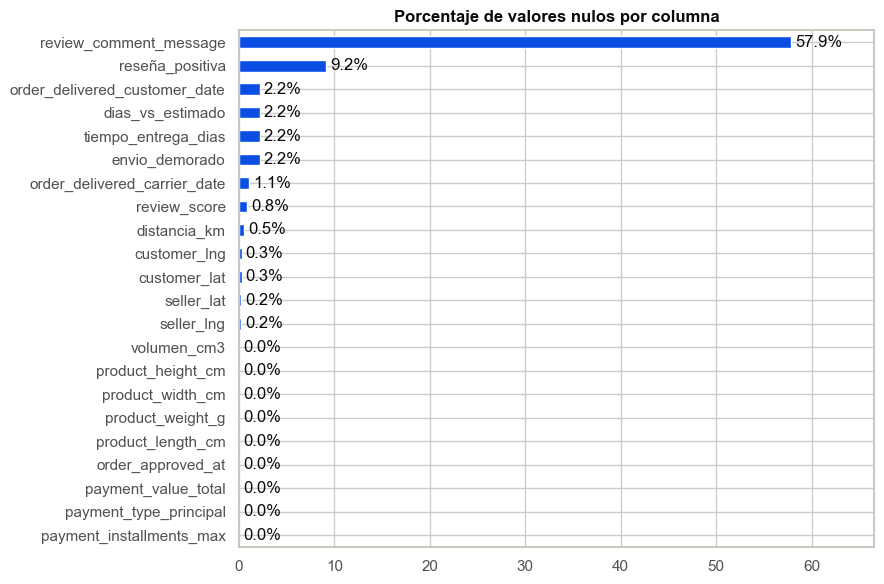

In [2]:
nulos_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]

fig, ax = plt.subplots(figsize=(9, 6))
barras = nulos_pct.plot(kind="barh", color=OLIST_BLUE, ax=ax)
ax.set_title("Porcentaje de valores nulos por columna")
ax.set_xlim(0, nulos_pct.max() * 1.15)
ax.bar_label(barras.containers[0], fmt="%.1f%%", padding=3)
ax.invert_yaxis()
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** las columnas con más nulos son las ligadas a **reviews sin comentario**, a **fechas de entrega de pedidos que nunca se entregaron** y a la **geolocalización** cuando el zip no matchea — todos **nulos estructurales**, no errores. Ninguna columna supera un nivel que obligue a descartarla del análisis.

## Gráfico 2 — Cantidad de pedidos únicos por mes

**Qué hacemos:** serie temporal mensual de pedidos únicos (`nunique` de `order_id` por `mes_compra`), con el valor anotado sobre cada punto.

**Para qué:** detectar **estacionalidad y picos de demanda** (Black Friday, fiestas) a lo largo de 2016-2018 — información relevante para planificar stock y logística.

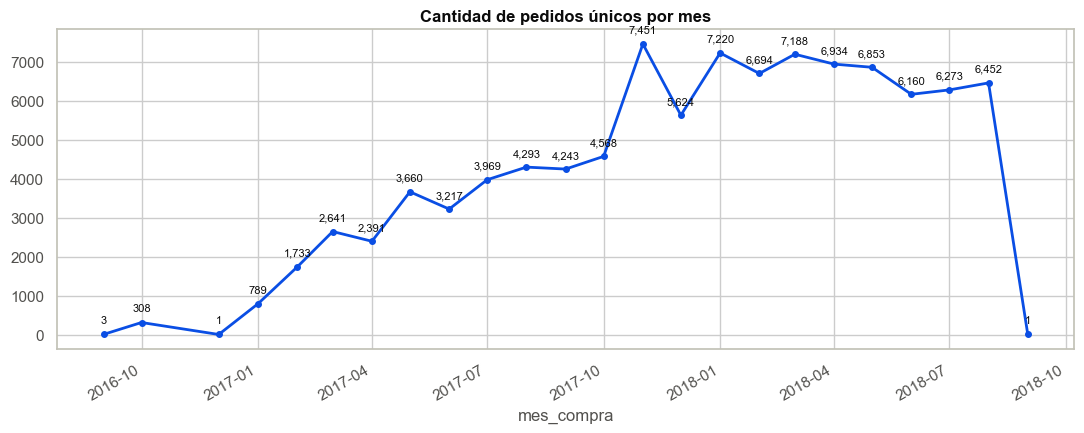

In [3]:
ventas_mensuales = df.groupby("mes_compra")["order_id"].nunique()

fig, ax = plt.subplots(figsize=(11, 4.5))
ventas_mensuales.plot(ax=ax, color=OLIST_BLUE, linewidth=2, marker="o", markersize=4)
for x, y in zip(ventas_mensuales.index, ventas_mensuales.values):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8)
ax.set_title("Cantidad de pedidos únicos por mes")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** se ve un **crecimiento sostenido de pedidos a lo largo de 2017** y un **pico marcado en noviembre de 2017 (Black Friday)**, seguido de una caída abrupta al final de la serie — esa caída corresponde a **datos incompletos del último mes**, no a una caída real de ventas.

## Gráfico 3 — Top 10 categorías de producto

**Qué hacemos:** barras horizontales con las 10 categorías de producto con más ítems vendidos, con la cantidad exacta al lado de cada barra.

**Para qué:** identificar **qué categorías concentran el volumen del negocio** — sirve tanto para pricing como para decidir dónde priorizar mejoras logísticas.

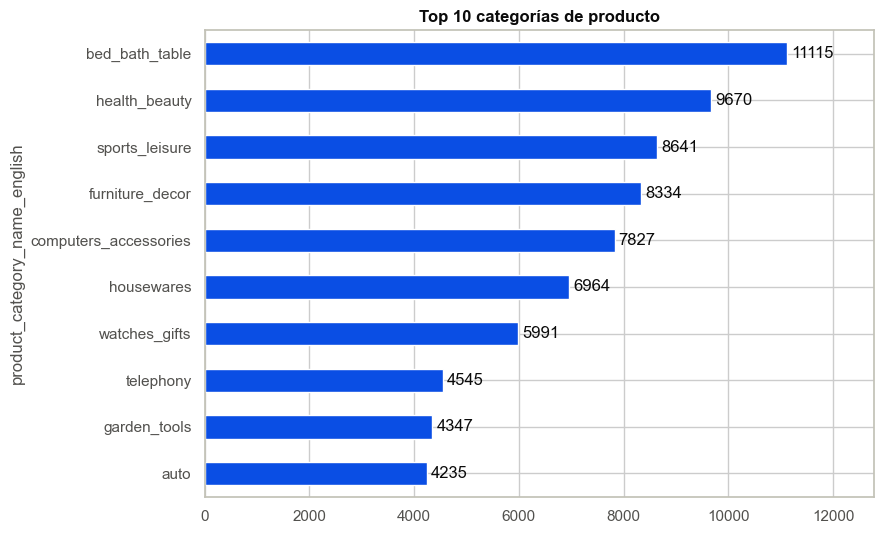

In [4]:
top_categorias = df["product_category_name_english"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
barras = top_categorias.plot(kind="barh", color=OLIST_BLUE, ax=ax)
ax.set_xlim(0, top_categorias.max() * 1.15)
ax.bar_label(barras.containers[0], fmt="%.0f", padding=3)
ax.set_title("Top 10 categorías de producto")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** categorías de **bajo valor unitario y alta rotación** (belleza/salud, artículos para el hogar) dominan el volumen, más que categorías de ticket alto.

## Gráfico 4 — Distribución de `review_score`

**Qué hacemos:** histograma de 1 a 5 estrellas con el conteo exacto sobre cada barra, coloreado por sentiment (rojo = 1-2 ★, amarillo = 3 ★, verde = 4-5 ★).

**Para qué:** ver si la satisfacción está **polarizada** (muchos 1 y muchos 5) o **concentrada** en valores intermedios, antes de binarizarla en `reseña_positiva` (notebook 04).

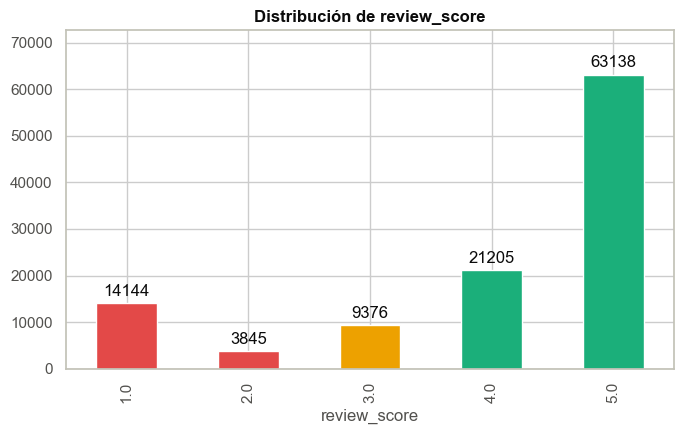

In [5]:
conteo_scores = df["review_score"].value_counts().sort_index()
colores_scores = [PALETA_CATEGORICA[7] if s <= 2 else (PALETA_CATEGORICA[3] if s == 3 else PALETA_CATEGORICA[2])
                   for s in conteo_scores.index]

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = conteo_scores.plot(kind="bar", color=colores_scores, ax=ax)
ax.set_ylim(0, conteo_scores.max() * 1.15)
ax.bar_label(barras.containers[0], fmt="%.0f", padding=3)
ax.set_title("Distribución de review_score")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** la distribución está claramente **sesgada hacia 5 estrellas**, con un segundo grupo más chico en **1 estrella** — hay pocas reseñas "tibias" (2 o 3 ★). Eso respalda el criterio de `reseña_positiva`: dejar el puntaje 3 como ambiguo (`NaN`) en vez de forzarlo a un lado.

## Gráfico 5 — Tiempo de entrega y desvío vs. fecha estimada

**Qué hacemos:** dos histogramas:

1. `tiempo_entrega_dias` — con su **media** marcada y anotada.
2. `dias_vs_estimado` — con la **línea 0** (= "llegó exactamente en la fecha prometida") y la media marcadas.

**Para qué:** entender la **variabilidad real** de los tiempos de entrega y cuán seguido (y por cuánto) Olist se pasa de la fecha que le prometió al cliente.

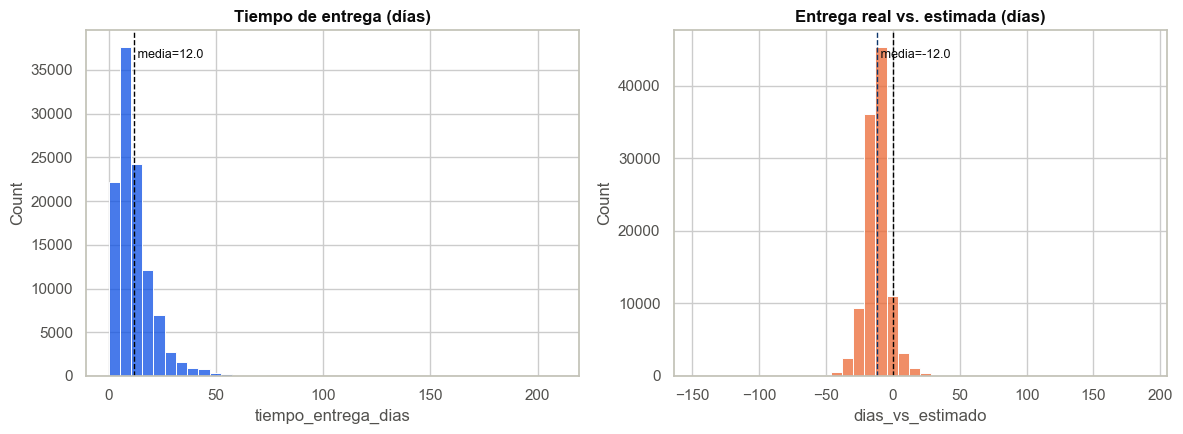

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

media1 = df["tiempo_entrega_dias"].mean()
sns.histplot(df["tiempo_entrega_dias"].dropna(), bins=40, color=OLIST_BLUE, ax=axes[0])
axes[0].axvline(media1, color="black", linestyle="--", linewidth=1)
axes[0].text(media1, axes[0].get_ylim()[1] * 0.92, f" media={media1:.1f}", fontsize=9)
axes[0].set_title("Tiempo de entrega (días)")

media2 = df["dias_vs_estimado"].mean()
sns.histplot(df["dias_vs_estimado"].dropna(), bins=40, color=PALETA_CATEGORICA[1], ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(media2, color=OLIST_BLUE_DARK, linestyle="--", linewidth=1)
axes[1].text(media2, axes[1].get_ylim()[1] * 0.92, f" media={media2:.1f}", fontsize=9)
axes[1].set_title("Entrega real vs. estimada (días)")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** la mayoría de los pedidos se entrega **bastante antes** de la fecha estimada (la media de `dias_vs_estimado` es negativa): Olist calcula sus estimaciones con un margen conservador. Por eso, **cuando ese margen no alcanza, el atraso resultante golpea más la satisfacción** — es la clave para entender la hipótesis 1 del notebook 10.

## Gráfico 6 — `review_score` según envío a tiempo / demorado

**Qué hacemos:** boxplot comparando la distribución de `review_score` entre pedidos **a tiempo (0)** y **demorados (1)**, con la mediana de cada grupo anotada; además imprimimos el promedio de cada grupo.

**Para qué:** es la **primera mirada visual a la hipótesis 1** ("la demora reduce la satisfacción") antes de contrastarla formalmente con un test estadístico en el notebook 10.

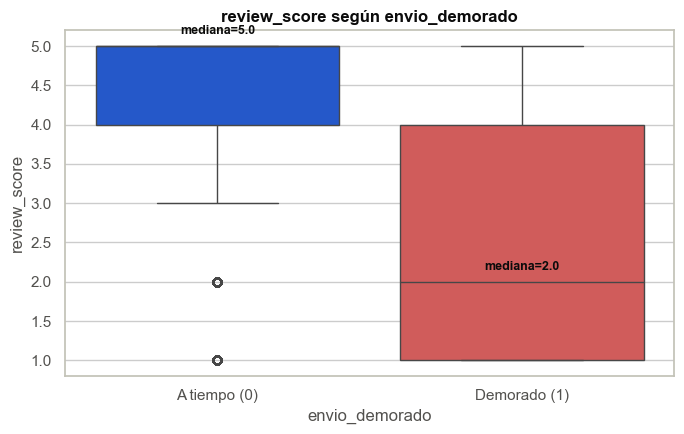

envio_demorado
0.0    4.21
1.0    2.55
Name: review_score, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    data=df.dropna(subset=["envio_demorado"]),
    x="envio_demorado", y="review_score",
    palette=[OLIST_BLUE, PALETA_CATEGORICA[7]], ax=ax,
)
medianas = df.dropna(subset=["envio_demorado"]).groupby("envio_demorado")["review_score"].median()
for i, val in enumerate(medianas):
    ax.text(i, val + 0.15, f"mediana={val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticklabels(["A tiempo (0)", "Demorado (1)"])
ax.set_title("review_score según envio_demorado")
plt.tight_layout()
guardar_fig()
plt.show()

df.groupby("envio_demorado")["review_score"].mean().round(2)

**Insight:** la mediana de `review_score` en los **envíos demorados es notoriamente más baja** que en los que llegaron a tiempo, con menos dispersión hacia el 5 — visualmente ya se anticipa que la hipótesis 1 se va a confirmar.

## Gráfico 7 — Cómo pagan los clientes

**Qué hacemos:** dos paneles: (a) torta del **medio de pago principal** con su %; (b) histograma de la **cantidad de cuotas** elegida, con la media marcada.

**Para qué:** entender el comportamiento de pago de los clientes de Olist — insumo de la hipótesis sobre si el medio de pago afecta la satisfacción.

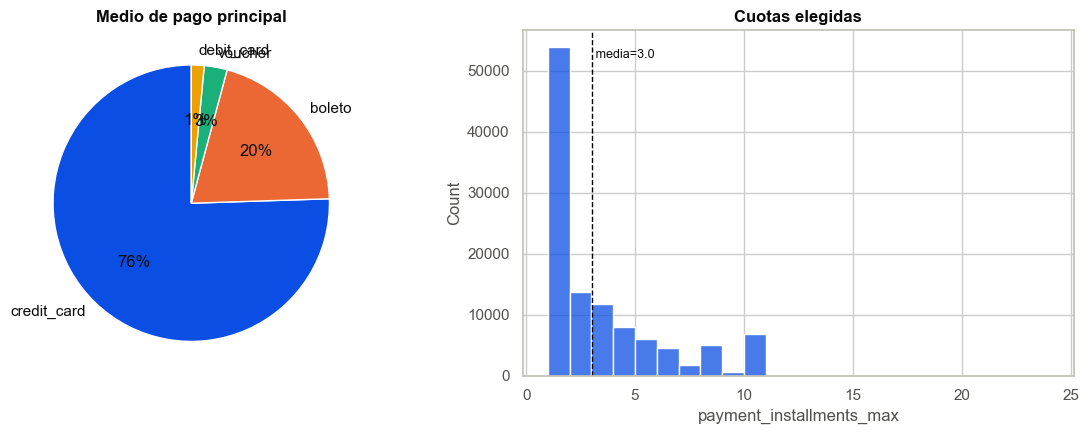

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
conteo_pago = df["payment_type_principal"].value_counts()
axes[0].pie(conteo_pago, labels=conteo_pago.index, autopct="%1.0f%%",
            colors=PALETA_CATEGORICA, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1})
axes[0].set_title("Medio de pago principal")

media_cuotas = df["payment_installments_max"].mean()
sns.histplot(df["payment_installments_max"].dropna(), bins=range(1, 25), color=OLIST_BLUE, ax=axes[1])
axes[1].axvline(media_cuotas, color="black", linestyle="--", linewidth=1)
axes[1].text(media_cuotas, axes[1].get_ylim()[1] * 0.92, f" media={media_cuotas:.1f}", fontsize=9)
axes[1].set_title("Cuotas elegidas")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** la **tarjeta de crédito domina** como medio de pago y, dentro de esa opción, la mayoría elige **pocas cuotas** — el crédito en cuotas no parece, por ahora, un factor determinante de insatisfacción por sí solo.

## Gráfico 8 — Precio dentro de las 10 categorías top

**Qué hacemos:** boxplots de `price` por cada una de las 10 categorías con más ítems vendidos (ordenadas por mediana), con la mediana de cada una anotada. Se omiten los outliers extremos (`showfliers=False`) para que se lea la caja.

**Para qué:** ver si las categorías de **mayor volumen** (gráfico 3) son también las de **mayor o menor ticket promedio** — esa distinción es relevante para decisiones de pricing/marketing.

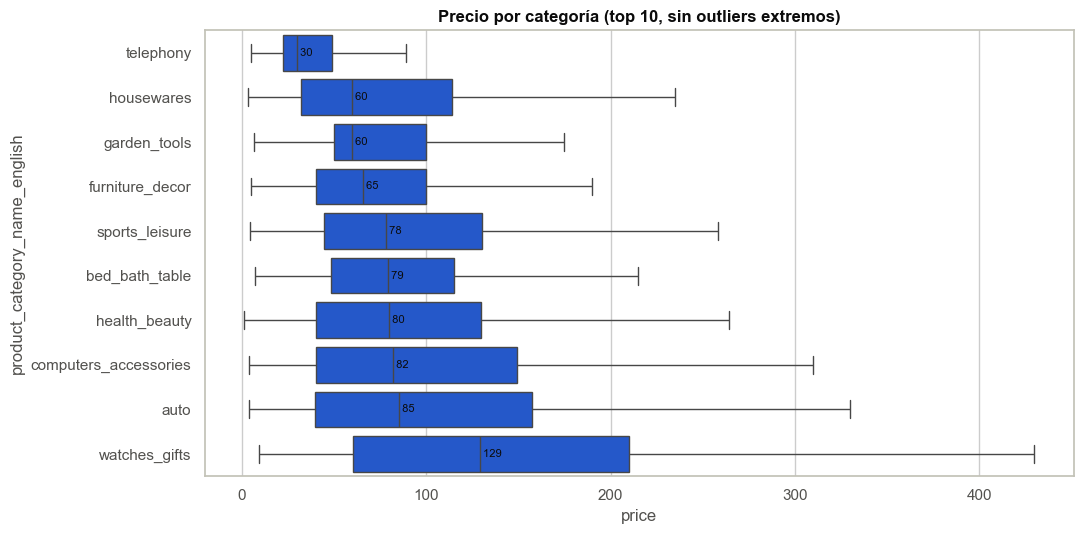

In [9]:
top10 = df["product_category_name_english"].value_counts().head(10).index
df_top10 = df[df["product_category_name_english"].isin(top10)]
orden = df_top10.groupby("product_category_name_english")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(data=df_top10, y="product_category_name_english", x="price",
            order=orden, color=OLIST_BLUE, ax=ax, showfliers=False)
medianas = df_top10.groupby("product_category_name_english")["price"].median().reindex(orden)
for i, val in enumerate(medianas):
    ax.text(val, i, f" {val:.0f}", va="center", fontsize=8)
ax.set_title("Precio por categoría (top 10, sin outliers extremos)")
plt.tight_layout()
guardar_fig()
plt.show()

**Insight:** las categorías de **mayor volumen** (belleza/salud, artículos para el hogar) tienen precios medianos **bajos**, mientras que categorías de menor volumen (por ejemplo, muebles) tienen tickets **más altos** — confirma que **volumen y precio unitario son ejes distintos del negocio**.

### Cierre de la sección

Los 8 gráficos dejaron el terreno preparado con preguntas concretas: *¿qué categorías concentran las demoras? ¿la distancia y el tamaño del paquete influyen? ¿cómo varía el ticket por región? ¿quiénes son los vendedores que más pesan?* — el notebook 07 las contesta una por una.

**Siguiente paso:** `07_analisis_exhaustivo_logistica.ipynb`.